MARKET MICROSTRUCTURE SIMULATION
Initializing AAPL order book at $150.00
  Added BID: $149.85, Qty: 10000
  Added BID: $149.70, Qty: 8000
  Added BID: $149.55, Qty: 6000
  Added ASK: $150.15, Qty: 10000
  Added ASK: $150.30, Qty: 8000
  Added ASK: $150.45, Qty: 6000
Initializing GC_FUTURE order book at $1800.00
  Added BID: $1798.20, Qty: 3000
  Added BID: $1796.40, Qty: 2400
  Added BID: $1794.60, Qty: 1800
  Added ASK: $1801.80, Qty: 3000
  Added ASK: $1803.60, Qty: 2400
  Added ASK: $1805.40, Qty: 1800
Initializing BTC order book at $50000.00
  Added BID: $49950.00, Qty: 1000
  Added BID: $49900.00, Qty: 800
  Added BID: $49850.00, Qty: 600
  Added ASK: $50050.00, Qty: 1000
  Added ASK: $50100.00, Qty: 800
  Added ASK: $50150.00, Qty: 600
Created 25 market makers
Created 11 informed traders
Created 38 noise traders
Initialized simulation with 100 traders and 3 assets

Starting simulation...
Duration: 300s, Steps: 300
--------------------------------------------------
Step 100/300 | 

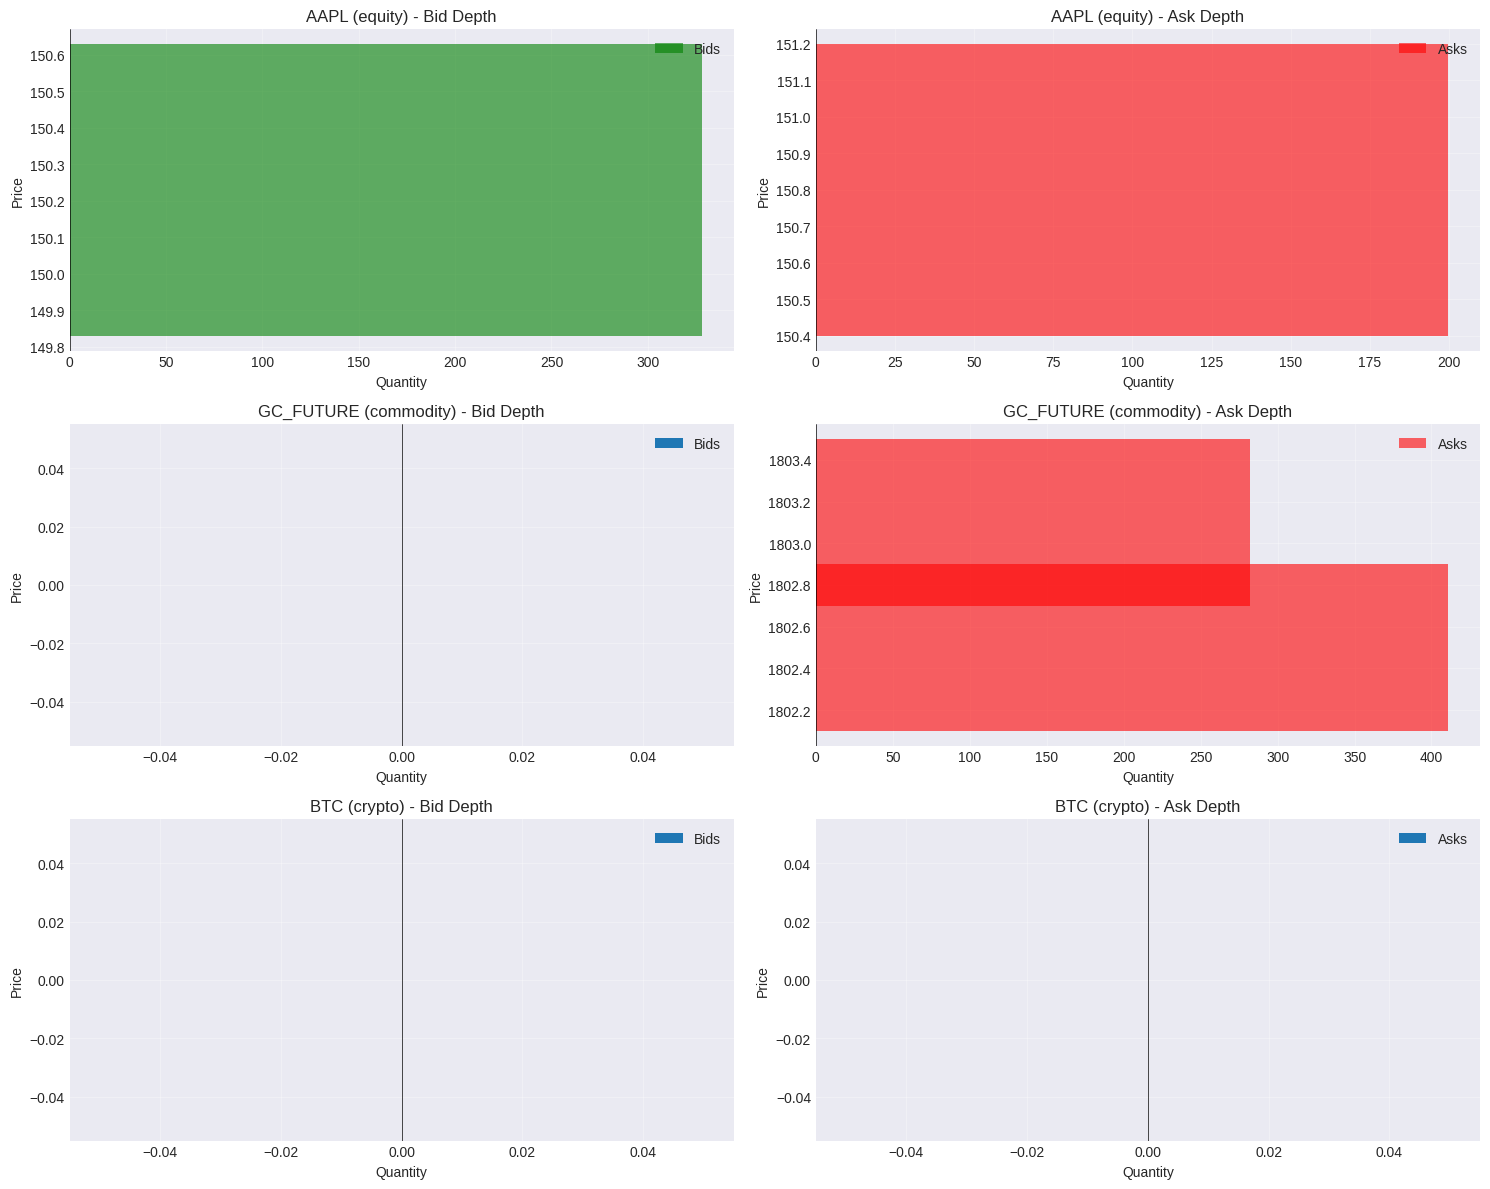

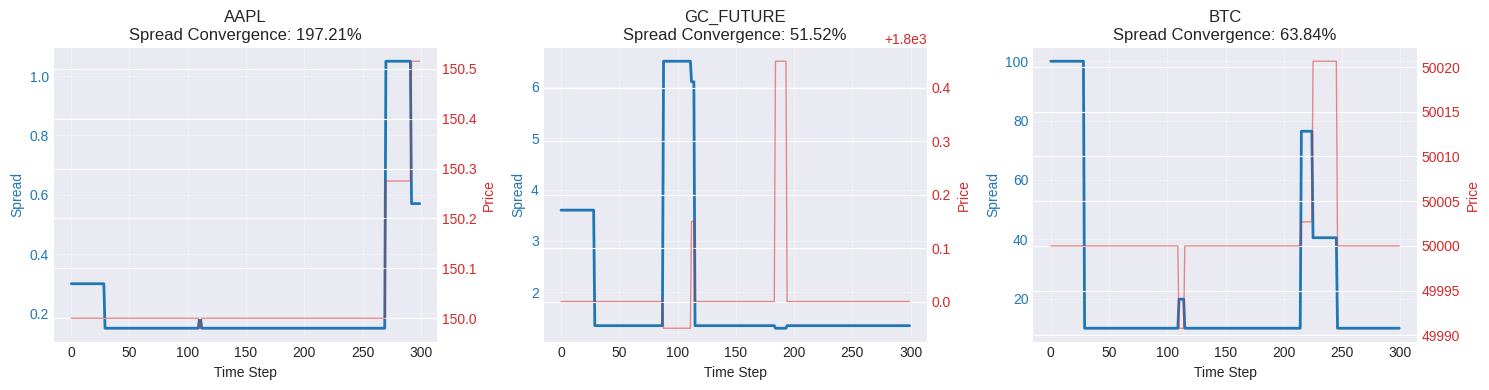

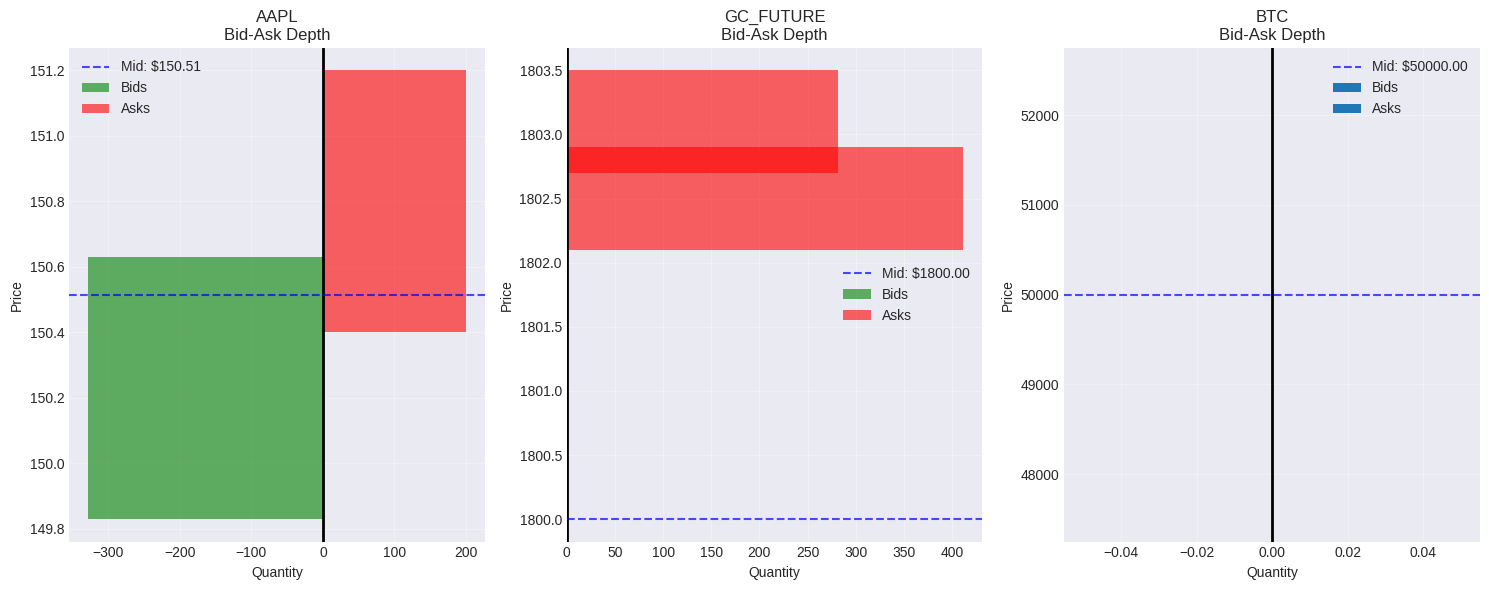

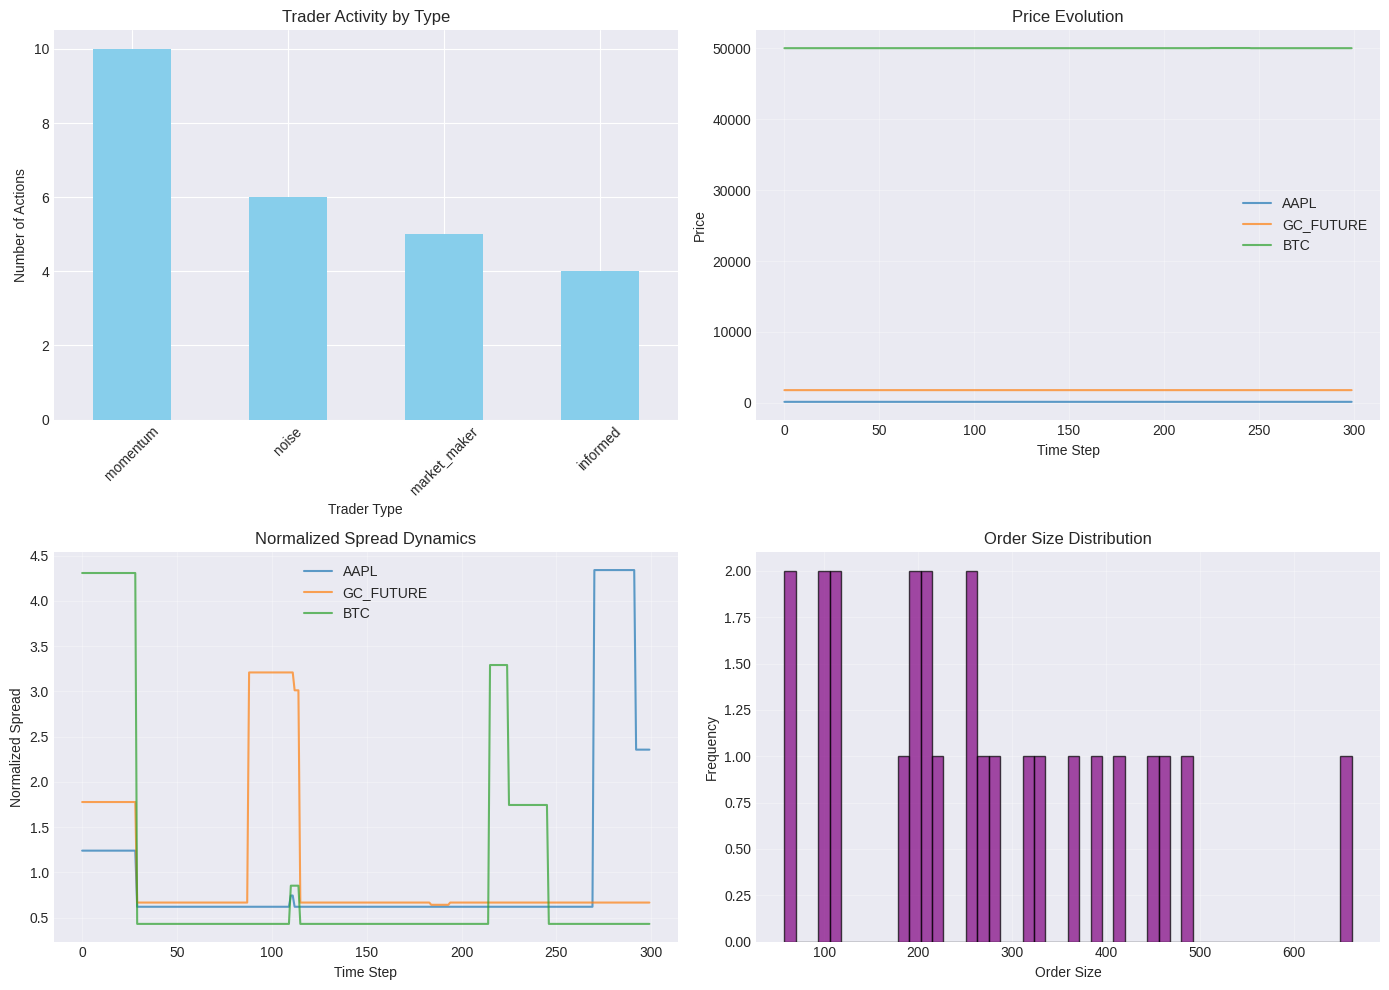

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import heapq
from datetime import datetime, timedelta
import random
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
from enum import Enum
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ========== ASSET AND TRADER CLASSES ==========
class AssetType(Enum):
    EQUITY = "equity"
    COMMODITY = "commodity"
    CRYPTO = "crypto"
    FUTURE = "future"

@dataclass
class Asset:
    name: str
    asset_type: AssetType
    tick_size: float
    initial_price: float
    spread_ratio: float = 0.001
    depth_scale: float = 1000
    volatility: float = 0.02

    def __post_init__(self):
        """Initialize asset-specific parameters"""
        if self.asset_type == AssetType.EQUITY:
            self.depth_scale *= 2
        elif self.asset_type == AssetType.COMMODITY:
            self.spread_ratio *= 1.5
        elif self.asset_type == AssetType.CRYPTO:
            self.tick_size *= 0.1
            self.volatility *= 2.0

class TraderType(Enum):
    MARKET_MAKER = "market_maker"
    INFORMED = "informed"
    NOISE = "noise"
    MOMENTUM = "momentum"

@dataclass
class Trader:
    id: int
    trader_type: TraderType
    capital: float
    inventory: float
    risk_aversion: float
    arrival_rate: float

    def generate_order_size(self) -> float:
        """Generate order size based on trader type"""
        if self.trader_type == TraderType.MARKET_MAKER:
            return np.random.uniform(50, 200)
        elif self.trader_type == TraderType.INFORMED:
            return np.random.uniform(200, 1000)
        else:
            return np.random.uniform(100, 500)

    def decide_action(self) -> Tuple[str, float, Optional[float]]:
        """Decide whether to place bid, ask, or market order"""
        actions = ['limit_bid', 'limit_ask', 'market', 'cancel']
        weights = [0.3, 0.3, 0.3, 0.1]

        action = np.random.choice(actions, p=weights)
        size = self.generate_order_size()

        if action in ['limit_bid', 'limit_ask']:
            price_offset = np.random.exponential(0.001)  # Small offset
            return action, size, price_offset
        elif action == 'market':
            return 'market', size, None
        else:
            return 'cancel', 0, None

# ========== LIMIT ORDER BOOK ==========
class LimitOrder:
    def __init__(self, order_id: int, trader_id: int, is_bid: bool, price: float,
                 quantity: float, timestamp: datetime):
        self.order_id = order_id
        self.trader_id = trader_id
        self.is_bid = is_bid
        self.price = price
        self.quantity = quantity
        self.timestamp = timestamp
        self.remaining_quantity = quantity

    def __lt__(self, other):
        # For priority queues
        if self.is_bid:
            return self.price > other.price  # Higher bids first
        else:
            return self.price < other.price  # Lower asks first

    def __repr__(self):
        return f"Order({self.order_id}, {'BID' if self.is_bid else 'ASK'}, ${self.price:.2f}, Qty:{self.remaining_quantity})"

class LimitOrderBook:
    def __init__(self, asset: Asset):
        self.asset = asset
        self.bids = []  # Max-heap for bids
        self.asks = []  # Min-heap for asks
        self.orders = {}  # order_id -> LimitOrder
        self.order_id_counter = 0
        self.mid_price_history = []
        self.spread_history = []

        # Initialize with some orders
        self._initialize_book()

    def _initialize_book(self):
        """Initialize the order book with starting liquidity"""
        mid_price = self.asset.initial_price
        spread = mid_price * self.asset.spread_ratio

        print(f"Initializing {self.asset.name} order book at ${mid_price:.2f}")

        # Create initial bids
        for i in range(3):
            price = mid_price * (1 - (i+1) * 0.001)
            price = round(price / self.asset.tick_size) * self.asset.tick_size
            quantity = self.asset.depth_scale * (1 - i * 0.2)

            order = LimitOrder(
                order_id=self.order_id_counter,
                trader_id=-1,
                is_bid=True,
                price=price,
                quantity=quantity,
                timestamp=datetime.now()
            )
            self.order_id_counter += 1

            heapq.heappush(self.bids, order)
            self.orders[order.order_id] = order
            print(f"  Added BID: ${price:.2f}, Qty: {quantity:.0f}")

        # Create initial asks
        for i in range(3):
            price = mid_price * (1 + (i+1) * 0.001)
            price = round(price / self.asset.tick_size) * self.asset.tick_size
            quantity = self.asset.depth_scale * (1 - i * 0.2)

            order = LimitOrder(
                order_id=self.order_id_counter,
                trader_id=-1,
                is_bid=False,
                price=price,
                quantity=quantity,
                timestamp=datetime.now()
            )
            self.order_id_counter += 1

            heapq.heappush(self.asks, order)
            self.orders[order.order_id] = order
            print(f"  Added ASK: ${price:.2f}, Qty: {quantity:.0f}")

    @property
    def best_bid(self) -> Optional[float]:
        if self.bids:
            return self.bids[0].price
        return None

    @property
    def best_ask(self) -> Optional[float]:
        if self.asks:
            return self.asks[0].price
        return None

    @property
    def spread(self) -> float:
        bid = self.best_bid
        ask = self.best_ask
        if bid and ask:
            return ask - bid
        return self.asset.initial_price * self.asset.spread_ratio

    @property
    def mid_price(self) -> float:
        bid = self.best_bid
        ask = self.best_ask
        if bid and ask:
            return (bid + ask) / 2
        return self.asset.initial_price

    def add_order(self, order: LimitOrder):
        """Add a new limit order to the book"""
        if order.is_bid:
            heapq.heappush(self.bids, order)
        else:
            heapq.heappush(self.asks, order)
        self.orders[order.order_id] = order

    def match_market_order(self, is_buy: bool, quantity: float, timestamp: datetime) -> Tuple[float, float]:
        """Execute a market order against the limit order book"""
        total_cost = 0
        filled_quantity = 0

        # Debug info
        if len(self.orders) != (len(self.bids) + len(self.asks)):
            print(f"WARNING: Order count mismatch! Orders: {len(self.orders)}, Bids: {len(self.bids)}, Asks: {len(self.asks)}")

        if is_buy:
            # Buying at ask prices
            while quantity > 0 and self.asks:
                if not self.asks:
                    break

                best_ask = self.asks[0]
                fill_qty = min(quantity, best_ask.remaining_quantity)

                total_cost += fill_qty * best_ask.price
                filled_quantity += fill_qty
                quantity -= fill_qty
                best_ask.remaining_quantity -= fill_qty

                if best_ask.remaining_quantity <= 0:
                    # Remove from heap
                    popped_order = heapq.heappop(self.asks)
                    # Check if order still exists in dictionary before deleting
                    if popped_order.order_id in self.orders:
                        del self.orders[popped_order.order_id]
        else:
            # Selling at bid prices
            while quantity > 0 and self.bids:
                if not self.bids:
                    break

                best_bid = self.bids[0]
                fill_qty = min(quantity, best_bid.remaining_quantity)

                total_cost += fill_qty * best_bid.price
                filled_quantity += fill_qty
                quantity -= fill_qty
                best_bid.remaining_quantity -= fill_qty

                if best_bid.remaining_quantity <= 0:
                    # Remove from heap
                    popped_order = heapq.heappop(self.bids)
                    # Check if order still exists in dictionary before deleting
                    if popped_order.order_id in self.orders:
                        del self.orders[popped_order.order_id]

        average_price = total_cost / filled_quantity if filled_quantity > 0 else 0
        return filled_quantity, average_price

    def cancel_order(self, order_id: int):
        """Cancel an existing order"""
        if order_id in self.orders:
            order = self.orders[order_id]
            # Remove from appropriate heap
            if order.is_bid:
                self.bids = [o for o in self.bids if o.order_id != order_id]
                heapq.heapify(self.bids)
            else:
                self.asks = [o for o in self.asks if o.order_id != order_id]
                heapq.heapify(self.asks)
            del self.orders[order_id]

    def clean_expired_orders(self, current_time: datetime, max_age_seconds: float = 30):
        """Remove orders that have expired"""
        expired_orders = []
        for order_id, order in list(self.orders.items()):
            age = (current_time - order.timestamp).total_seconds()
            if age > max_age_seconds:
                expired_orders.append(order_id)

        for order_id in expired_orders:
            self.cancel_order(order_id)

    def get_depth_profile(self, levels: int = 10) -> Tuple[List[Tuple[float, float]], List[Tuple[float, float]]]:
        """Get bid and ask depth profiles"""
        # Aggregate bids by price
        bid_agg = defaultdict(float)
        for order in self.bids:
            price_rounded = round(order.price / self.asset.tick_size) * self.asset.tick_size
            bid_agg[price_rounded] += order.remaining_quantity

        # Aggregate asks by price
        ask_agg = defaultdict(float)
        for order in self.asks:
            price_rounded = round(order.price / self.asset.tick_size) * self.asset.tick_size
            ask_agg[price_rounded] += order.remaining_quantity

        # Sort and take top levels
        sorted_bids = sorted(bid_agg.items(), key=lambda x: x[0], reverse=True)[:levels]
        sorted_asks = sorted(ask_agg.items(), key=lambda x: x[0])[:levels]

        return sorted_bids, sorted_asks

    def record_state(self):
        """Record current state for analysis"""
        self.mid_price_history.append(self.mid_price)
        self.spread_history.append(self.spread)

# ========== SIMULATION ENGINE ==========
class MarketSimulation:
    def __init__(self, assets: List[Asset], n_traders: int = 100,
                 simulation_duration: float = 600, time_step: float = 1.0):
        self.assets = assets
        self.n_traders = n_traders
        self.simulation_duration = simulation_duration  # seconds
        self.time_step = time_step

        # Initialize order books
        self.order_books = {asset.name: LimitOrderBook(asset) for asset in assets}

        # Initialize traders
        self.traders = self._initialize_traders()

        # Statistics
        self.transaction_log = []
        self.current_time = datetime.now()

        print(f"Initialized simulation with {n_traders} traders and {len(assets)} assets")

    def _initialize_traders(self) -> List[Trader]:
        """Initialize traders with different strategies"""
        traders = []

        for i in range(self.n_traders):
            # Assign trader type
            rand = np.random.random()
            if rand < 0.2:
                trader_type = TraderType.MARKET_MAKER
            elif rand < 0.4:
                trader_type = TraderType.INFORMED
            elif rand < 0.7:
                trader_type = TraderType.NOISE
            else:
                trader_type = TraderType.MOMENTUM

            trader = Trader(
                id=i,
                trader_type=trader_type,
                capital=np.random.lognormal(10, 1) * 100000,
                inventory=np.random.normal(0, 1000),
                risk_aversion=np.random.uniform(0.5, 2.0),
                arrival_rate=np.random.exponential(5)
            )
            traders.append(trader)

        print(f"Created {len([t for t in traders if t.trader_type == TraderType.MARKET_MAKER])} market makers")
        print(f"Created {len([t for t in traders if t.trader_type == TraderType.INFORMED])} informed traders")
        print(f"Created {len([t for t in traders if t.trader_type == TraderType.NOISE])} noise traders")
        return traders

    def run_simulation(self):
        """Run the main simulation loop"""
        n_steps = int(self.simulation_duration / self.time_step)

        print(f"\nStarting simulation...")
        print(f"Duration: {self.simulation_duration}s, Steps: {n_steps}")
        print("-" * 50)

        for step in range(n_steps):
            self.current_time += timedelta(seconds=self.time_step)

            if step % 100 == 0 and step > 0:
                print(f"Step {step}/{n_steps} | Time: {step} seconds")

            # Process each trader
            for trader in self.traders:
                # Poisson arrival
                if np.random.poisson(trader.arrival_rate * self.time_step / 3600) > 0:
                    # Randomly choose an asset
                    asset = np.random.choice(self.assets)
                    order_book = self.order_books[asset.name]

                    # Trader decides action
                    action, size, price_offset = trader.decide_action()

                    if action == 'limit_bid' and price_offset:
                        # Place limit bid
                        price = order_book.mid_price * (1 - price_offset)
                        price = round(price / asset.tick_size) * asset.tick_size

                        order = LimitOrder(
                            order_id=order_book.order_id_counter,
                            trader_id=trader.id,
                            is_bid=True,
                            price=price,
                            quantity=size,
                            timestamp=self.current_time
                        )
                        order_book.order_id_counter += 1
                        order_book.add_order(order)

                        self.transaction_log.append({
                            'timestamp': self.current_time,
                            'trader_id': trader.id,
                            'trader_type': trader.trader_type.value,
                            'asset': asset.name,
                            'action': 'limit_bid',
                            'price': price,
                            'quantity': size
                        })

                    elif action == 'limit_ask' and price_offset:
                        # Place limit ask
                        price = order_book.mid_price * (1 + price_offset)
                        price = round(price / asset.tick_size) * asset.tick_size

                        order = LimitOrder(
                            order_id=order_book.order_id_counter,
                            trader_id=trader.id,
                            is_bid=False,
                            price=price,
                            quantity=size,
                            timestamp=self.current_time
                        )
                        order_book.order_id_counter += 1
                        order_book.add_order(order)

                        self.transaction_log.append({
                            'timestamp': self.current_time,
                            'trader_id': trader.id,
                            'trader_type': trader.trader_type.value,
                            'asset': asset.name,
                            'action': 'limit_ask',
                            'price': price,
                            'quantity': size
                        })

                    elif action == 'market' and size > 0:
                        # Execute market order
                        is_buy = np.random.random() > 0.5
                        filled_qty, avg_price = order_book.match_market_order(is_buy, size, self.current_time)

                        if filled_qty > 0:
                            self.transaction_log.append({
                                'timestamp': self.current_time,
                                'trader_id': trader.id,
                                'trader_type': trader.trader_type.value,
                                'asset': asset.name,
                                'action': 'market_buy' if is_buy else 'market_sell',
                                'price': avg_price,
                                'quantity': filled_qty
                            })

                    elif action == 'cancel':
                        # Cancel a random order
                        if order_book.orders and np.random.random() < 0.1:
                            order_id_to_cancel = np.random.choice(list(order_book.orders.keys()))
                            order_book.cancel_order(order_id_to_cancel)

            # Clean expired orders and record state
            for order_book in self.order_books.values():
                order_book.clean_expired_orders(self.current_time)
                order_book.record_state()

        print("\nSimulation completed!")
        print(f"Total transactions: {len(self.transaction_log)}")

    def analyze_results(self):
        """Analyze simulation results"""
        results = {}

        for asset_name, order_book in self.order_books.items():
            # Get depth profile
            bids, asks = order_book.get_depth_profile(levels=10)

            # Calculate statistics
            spreads = np.array(order_book.spread_history)
            prices = np.array(order_book.mid_price_history)

            # Avoid division by zero
            if len(prices) > 1:
                returns = np.diff(prices) / prices[:-1]
                volatility = np.std(returns) * np.sqrt(252 * 6.5 * 3600) if len(returns) > 0 else 0
            else:
                volatility = 0

            results[asset_name] = {
                'final_mid_price': order_book.mid_price,
                'spread_mean': np.mean(spreads) if len(spreads) > 0 else 0,
                'spread_std': np.std(spreads) if len(spreads) > 0 else 0,
                'volatility': volatility,
                'total_transactions': len([t for t in self.transaction_log if t['asset'] == asset_name]),
                'depth_profile': {
                    'bids': bids,
                    'asks': asks
                },
                'price_history': order_book.mid_price_history,
                'spread_history': order_book.spread_history
            }

        return results

# ========== VISUALIZATION FUNCTIONS ==========
def plot_depth_charts(assets: List[Asset], simulation_results: dict):
    """Plot depth charts for different asset types"""
    n_assets = len(assets)
    fig, axes = plt.subplots(n_assets, 2, figsize=(15, 4*n_assets), squeeze=False)

    for idx, asset in enumerate(assets):
        asset_name = asset.name
        results = simulation_results[asset_name]

        bids = results['depth_profile']['bids']
        asks = results['depth_profile']['asks']

        # Extract prices and quantities
        if bids:
            bid_prices = [p for p, _ in bids]
            bid_quantities = [q for _, q in bids]
        else:
            bid_prices, bid_quantities = [], []

        if asks:
            ask_prices = [p for p, _ in asks]
            ask_quantities = [q for _, q in asks]
        else:
            ask_prices, ask_quantities = [], []

        # Plot bid depth
        axes[idx, 0].barh(bid_prices, bid_quantities, color='green', alpha=0.6, label='Bids')
        axes[idx, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        axes[idx, 0].set_xlabel('Quantity')
        axes[idx, 0].set_ylabel('Price')
        axes[idx, 0].set_title(f'{asset_name} ({asset.asset_type.value}) - Bid Depth')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)

        # Plot ask depth
        axes[idx, 1].barh(ask_prices, ask_quantities, color='red', alpha=0.6, label='Asks')
        axes[idx, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        axes[idx, 1].set_xlabel('Quantity')
        axes[idx, 1].set_ylabel('Price')
        axes[idx, 1].set_title(f'{asset_name} ({asset.asset_type.value}) - Ask Depth')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_spread_convergence(simulation_results: dict):
    """Plot spread convergence over time"""
    n_assets = len(simulation_results)
    fig, axes = plt.subplots(1, n_assets, figsize=(5*n_assets, 4), squeeze=False)

    for idx, (asset_name, results) in enumerate(simulation_results.items()):
        ax = axes[0, idx]

        spreads = results['spread_history']
        prices = results['price_history']

        times = list(range(len(spreads)))

        # Plot spread
        color = 'tab:blue'
        ax.plot(times, spreads, color=color, linewidth=2)
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Spread', color=color)
        ax.tick_params(axis='y', labelcolor=color)

        # Add price on secondary axis
        ax2 = ax.twinx()
        color = 'tab:red'
        ax2.plot(times, prices, color=color, alpha=0.5, linewidth=1)
        ax2.set_ylabel('Price', color=color)
        ax2.tick_params(axis='y', labelcolor=color)

        # Calculate and display convergence
        if len(spreads) > 100:
            initial_avg = np.mean(spreads[:100])
            final_avg = np.mean(spreads[-100:]) if len(spreads) >= 100 else spreads[-1]
            convergence = final_avg / initial_avg

            ax.set_title(f'{asset_name}\nSpread Convergence: {convergence:.2%}')
        else:
            ax.set_title(f'{asset_name}')

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_combined_depth(simulation_results: dict):
    """Plot combined bid-ask depth charts"""
    n_assets = len(simulation_results)
    fig, axes = plt.subplots(1, n_assets, figsize=(5*n_assets, 6), squeeze=False)

    for idx, (asset_name, results) in enumerate(simulation_results.items()):
        ax = axes[0, idx]

        bids = results['depth_profile']['bids']
        asks = results['depth_profile']['asks']

        # Combine all prices
        all_bid_prices = [p for p, _ in bids]
        all_ask_prices = [p for p, _ in asks]
        all_prices = sorted(set(all_bid_prices + all_ask_prices))

        # Create dictionaries for quick lookup
        bid_dict = dict(bids)
        ask_dict = dict(asks)

        bid_quantities = [bid_dict.get(p, 0) for p in all_prices]
        ask_quantities = [ask_dict.get(p, 0) for p in all_prices]

        # Plot combined depth
        ax.barh(all_prices, [-q for q in bid_quantities], color='green', alpha=0.6, label='Bids')
        ax.barh(all_prices, ask_quantities, color='red', alpha=0.6, label='Asks')

        ax.axvline(x=0, color='black', linewidth=2)
        ax.set_xlabel('Quantity')
        ax.set_ylabel('Price')
        ax.set_title(f'{asset_name}\nBid-Ask Depth')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Add mid-price line
        mid_price = results['final_mid_price']
        ax.axhline(y=mid_price, color='blue', linestyle='--', alpha=0.7,
                  label=f'Mid: ${mid_price:.2f}')
        ax.legend()

    plt.tight_layout()
    plt.show()

def plot_market_analysis(transaction_log: list, simulation_results: dict):
    """Plot market analysis and trader activity"""
    if not transaction_log:
        print("No transactions to analyze")
        return

    df = pd.DataFrame(transaction_log)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Trader activity by type
    ax1 = axes[0, 0]
    if 'trader_type' in df.columns:
        activity = df['trader_type'].value_counts()
        activity.plot(kind='bar', ax=ax1, color='skyblue')
        ax1.set_title('Trader Activity by Type')
        ax1.set_xlabel('Trader Type')
        ax1.set_ylabel('Number of Actions')
        ax1.tick_params(axis='x', rotation=45)

    # Plot 2: Price impact analysis
    ax2 = axes[0, 1]
    for asset_name, results in simulation_results.items():
        prices = results['price_history']
        ax2.plot(prices, label=asset_name, alpha=0.7)
    ax2.set_title('Price Evolution')
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Price')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Spread dynamics
    ax3 = axes[1, 0]
    for asset_name, results in simulation_results.items():
        spreads = results['spread_history']
        # Normalize for comparison
        if len(spreads) > 0:
            normalized_spreads = spreads / np.mean(spreads)
            ax3.plot(normalized_spreads, label=asset_name, alpha=0.7)
    ax3.set_title('Normalized Spread Dynamics')
    ax3.set_xlabel('Time Step')
    ax3.set_ylabel('Normalized Spread')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Order size distribution
    ax4 = axes[1, 1]
    if 'quantity' in df.columns:
        ax4.hist(df['quantity'], bins=50, alpha=0.7, color='purple', edgecolor='black')
        ax4.set_title('Order Size Distribution')
        ax4.set_xlabel('Order Size')
        ax4.set_ylabel('Frequency')
        ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ========== MAIN SIMULATION ==========
def main():
    """Main simulation execution"""
    # Define assets with different characteristics
    assets = [
        Asset(
            name="AAPL",
            asset_type=AssetType.EQUITY,
            tick_size=0.01,
            initial_price=150.0,
            spread_ratio=0.001,
            depth_scale=5000
        ),
        Asset(
            name="GC_FUTURE",
            asset_type=AssetType.COMMODITY,
            tick_size=0.1,
            initial_price=1800.0,
            spread_ratio=0.0005,
            depth_scale=3000
        ),
        Asset(
            name="BTC",
            asset_type=AssetType.CRYPTO,
            tick_size=1.0,
            initial_price=50000.0,
            spread_ratio=0.0002,
            depth_scale=1000
        )
    ]

    print("=" * 60)
    print("MARKET MICROSTRUCTURE SIMULATION")
    print("=" * 60)

    # Create and run simulation (with fewer traders for faster execution)
    simulation = MarketSimulation(
        assets=assets,
        n_traders=100,  # Reduced from 1000 for faster testing
        simulation_duration=300,  # 5 minutes
        time_step=1.0
    )

    simulation.run_simulation()

    # Analyze results
    results = simulation.analyze_results()

    # Print summary
    print("\n" + "=" * 60)
    print("RESULTS SUMMARY")
    print("=" * 60)

    for asset_name, asset_results in results.items():
        print(f"\n{asset_name}:")
        print(f"  Final Price: ${asset_results['final_mid_price']:.2f}")
        print(f"  Avg Spread: ${asset_results['spread_mean']:.4f}")
        print(f"  Spread Std: ${asset_results['spread_std']:.4f}")
        print(f"  Annual Vol: {asset_results['volatility']:.2%}")
        print(f"  Transactions: {asset_results['total_transactions']}")

        # Show depth at best bid/ask
        bids = asset_results['depth_profile']['bids']
        asks = asset_results['depth_profile']['asks']
        if bids:
            print(f"  Best Bid: ${bids[0][0]:.2f} (Qty: {bids[0][1]:.0f})")
        if asks:
            print(f"  Best Ask: ${asks[0][0]:.2f} (Qty: {asks[0][1]:.0f})")

    # Generate visualizations
    print("\n" + "=" * 60)
    print("GENERATING VISUALIZATIONS")
    print("=" * 60)

    # 1. Depth charts
    plot_depth_charts(assets, results)

    # 2. Spread convergence
    plot_spread_convergence(results)

    # 3. Combined depth charts
    plot_combined_depth(results)

    # 4. Market analysis
    plot_market_analysis(simulation.transaction_log, results)

    return simulation, results

# Run the simulation
if __name__ == "__main__":
    simulation, results = main()